In [1]:
import os
import sys

# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

from frank2d import *
from optimization import *
from frank.utilities import UVDataBinner


In [2]:
rad_to_arcsec = 3600 * 180 / np.pi

AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc':18.6, 'pa':169 , 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout':0.518*2, 'disk_name': 'HD143006'}

data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum_gridded_N200.txt"


# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

# Frank Parameters
N = 50
 # load data
u, v, Re, Im, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Im*1j

geom = Geometry(inc= inc, pa= pa, dra= dra, ddec= ddec)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_4736/1189423384.py:3: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(np.hypot(u, v), Weights**(-1), ls = '--')


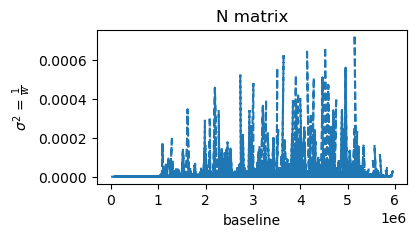

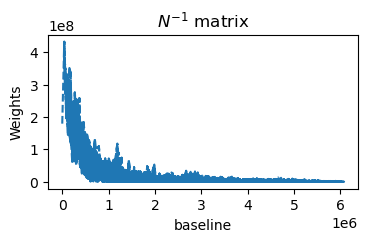

In [3]:
# error 
plt.figure(figsize=(4, 2))
plt.plot(np.hypot(u, v), Weights**(-1), ls = '--')
plt.xlabel("baseline")
plt.ylabel(r'$\sigma^{2}$ = $\frac{1}{w}$')
plt.title("N matrix")
plt.show()

# weights 
plt.figure(figsize=(4, 2))
plt.plot(np.hypot(u, v), Weights, ls = '--')
plt.xlabel("baseline")
plt.ylabel(r'Weights')
plt.title(r'$N^{-1}$ matrix')
plt.show()

In [4]:
import time
start_time = time.time()
FF = FourierBesselFitter(r_out, N, geom)
sol = FF.fit(u, v, Vis, Weights)
total_time = time.time() - start_time
print("--- %s minutes ---", total_time/60, " or ", total_time, " seconds.")

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: divide by zero encountered in log
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)
/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/optimization.py:381: RuntimeWarning: invalid value encountered in scalar multiply
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)


Minimum frequency in the data: 42971.83463481175
Maximum frequency in the data: 1519283.783515117
--- %s minutes --- 0.7950774629910787  or  47.70464777946472  seconds.


In [5]:
GM = FF._GaussianModel

In [6]:
trial = 8

In [7]:
GM.optimize_posterior()

....................................OPTIMIZING.................................. 
                 --------------> Initial parameters: m, c, log_l: -2 8 6
                 --------------> Bounds for m, log_c: (-6, -1.9) (7, 30)


  0%|                                                   | 0/200 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████| 200/200 [3:50:35<00:00, 69.18s/it]


acceptance ≈ 0.041 | steps=200 | burn=50
MAP: [-3.12738206 16.59799875  5.83760315]  median: [-2.9399997  13.96421326  5.93712481]  [-, +]: [1.07015247 4.35974219 0.67903293] [0.59633522 8.93601417 0.34441104]
                 --------------> Best parameters founded for: m, log_c:  -3.1273820590266195 16.597998752919978 5.837603148459563
--- 231.49089293082554 minutes to minimizing ---
                 --------------> Fitting with m, c, log_l: -3.1273820590266195 3.962768963415794e+16 5.837603148459563
....................................OPTIMIZING.................................. 


In [8]:
sampler = GM.sampler
samples = GM.samples

In [9]:
sampler.acceptance_fraction.mean()

0.0406

In [10]:
import pickle

payload = {
    "acceptance_fraction": sampler.acceptance_fraction.mean(), 
    "samples": samples,
    "chain": sampler.get_chain(),                 # shape: (nsteps, nwalkers, ndim)
    "log_prob": sampler.get_log_prob(),          # shape: (nsteps, nwalkers)
    "blobs": sampler.get_blobs(),
    "last_state": sampler.get_last_sample(),     # emcee.State (coords, log_prob, blobs, random_state)
    "nwalkers": sampler.nwalkers,
    "ndim": sampler.ndim,
    "rng": np.random.get_state(),                # por si quieres reanudar con el mismo RNG
}

filename = "emcee_run_"+ str(trial) + ".pkl"
with open(filename, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

In [11]:
GM._best

array([-3.12738206, 16.59799875,  5.83760315])

In [12]:
m = GM.samples[:, 0]
logc = GM.samples[:, 1]
logl = GM.samples[:, 2]
logp = GM.samples_logp

In [13]:
imax = np.argmax(logp)
i2max =  np.argsort(logp)[-50] # orden ascendente

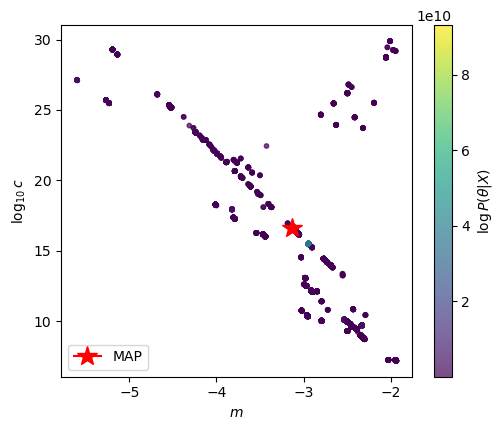

In [14]:
plt.figure(figsize=(5.2, 4.4))
sc = plt.scatter(m, logc, c=logp, s=10, alpha=0.7, cmap="viridis")
plt.plot(m[imax], logc[imax], marker="*", ms=15, color="red", label="MAP")
#plt.plot(m[i2max], logc[i2max], marker="*", ms=15, color="blue", label="MAP")
plt.colorbar(sc, label=r"$\log P(\theta|X)$")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
plt.legend()
plt.tight_layout()
plt.show()

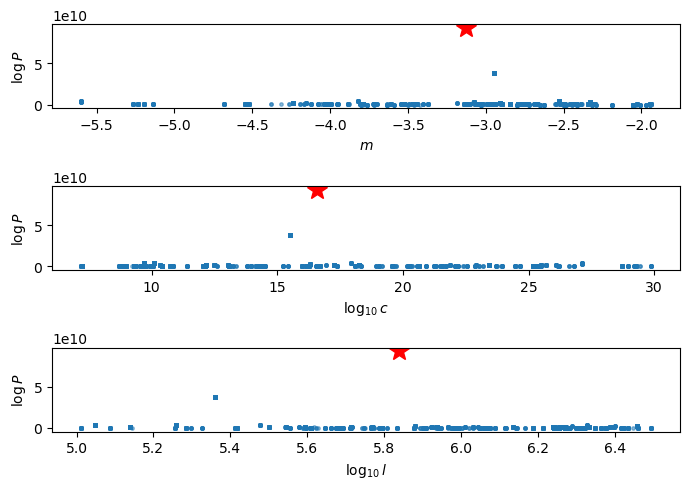

In [15]:
# Dispersión directa
fig, axs = plt.subplots(3, 1, figsize=(7, 5), sharey=True)
axs[0].scatter(m, logp, s=6, alpha=0.5)
axs[0].set_xlabel(r"$m$")
axs[0].set_ylabel(r"$\log P$")
axs[0].plot(m[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")


axs[1].set_ylabel(r"$\log P$")
axs[1].scatter(logc, logp, s=6, alpha=0.5)
axs[1].plot(logc[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")
axs[1].set_xlabel(r"$\log_{10} c$")


axs[2].set_ylabel(r"$\log P$")
axs[2].scatter(logl, logp, s=6, alpha=0.5)
axs[2].plot(logl[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")
axs[2].set_xlabel(r"$\log_{10} l$")

plt.tight_layout(); plt.show()

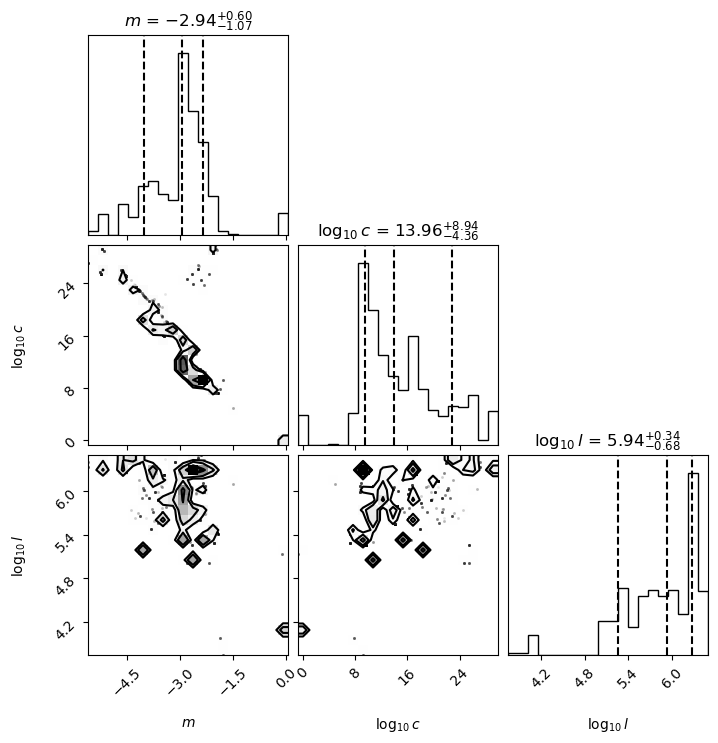

In [16]:
import corner
flat_samples = GM.samples

corner.corner(
    flat_samples,
    labels=[r"$m$", r"$\log_{10} c$", r"$\log_{10} l$" ],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    bins=20
)


plt.show()

In [17]:
m_best, log_c_best, logl_best = GM._best
print(m_best, log_c_best, logl_best)

-3.1273820590266195 16.597998752919978 5.837603148459563


In [18]:
#m_best, log_c_best = [-3.22, 14.63]

In [19]:
GM.one_fit([m_best, log_c_best, logl_best ])

                 --------------> Fitting with m, c, log_l: -3.1273820590266195 3.962768963415794e+16 5.837603148459563


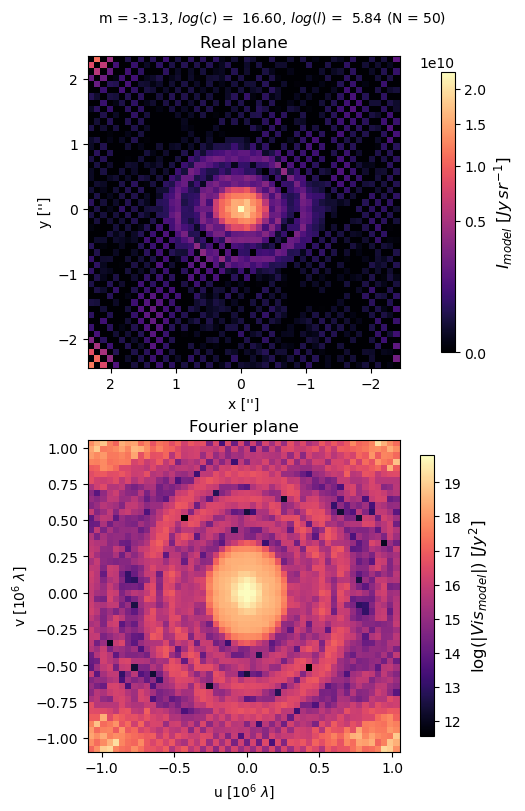

In [22]:
I = FF._GaussianModel._mu
I_reshape = I.reshape(N, N)
r_out_rad = r_out

import matplotlib.colors as colors

x_f1d = FF._DFT._Xn * rad_to_arcsec
y_f1d = FF._DFT._Yn * rad_to_arcsec
u_f1d = FF._DFT._Un
v_f1d = FF._DFT._Vn

fig, axs = plt.subplots(2, 1, figsize=(5, 8), constrained_layout=True)  # 1 columna, 2 filas
# --- Panel 1: Real plane ---
norm = colors.PowerNorm(gamma=0.5, vmin=0)

fig.suptitle(f' m = {m_best:.2f}, $log(c) $ =  {log_c_best:.2f}, $log(l) $ =  {logl_best:.2f} (N = ' + str(N) + ')' , fontsize=10)

plot1 = axs[0].pcolormesh(x_f1d.reshape(N, N),
                          y_f1d.reshape(N, N),
                          I_reshape, cmap="magma", norm=norm)
cbar1 = fig.colorbar(plot1, ax=axs[0], shrink = 0.9)
cbar1.set_label(r'$I_{model}$ [$Jy\, sr^{-1}$]', size=12)
axs[0].invert_xaxis()
axs[0].set_title(r'Real plane')
axs[0].set_xlabel("x ['']")
axs[0].set_ylabel("y ['']")
axs[0].set_aspect(1)

# --- Panel 2: Fourier plane ---
plot2 = axs[1].pcolormesh(np.fft.fftshift(u_f1d.reshape(N, N))/1e6,
                          np.fft.fftshift(v_f1d.reshape(N, N))/1e6,
                          np.log(np.fft.fftshift(np.abs(np.fft.ifft2(I_reshape)))),
                          cmap="magma")
cbar2 = fig.colorbar(plot2, ax=axs[1], shrink = 0.9)
cbar2.set_label(r'$\log(|Vis_{model}|)$ [$Jy^{2}$]', size=12)
axs[1].set_title(r'Fourier plane')
axs[1].set_xlabel(r'u [10$^{6}$ $\lambda$]')
axs[1].set_ylabel(r'v [10$^{6}$ $\lambda$]')
axs[1].set_aspect(1)

plt.show()

## Reparametrization

In [ ]:
import pickle
filename = "emcee_run_"+ str(3) + ".pkl"
with open(filename, "rb") as f:
    file = pickle.load(f)

In [ ]:
chain = file["chain"]
logp = file["log_prob"]

In [ ]:
burn = 30
flat_samples = chain[burn:, :, :].reshape(-1, chain.shape[-1])

m    = flat_samples[:, 0]
logc = flat_samples[:, 1]
logp = logp[burn:, :].reshape(-1) 


In [ ]:
len(m)

In [ ]:
weights = np.exp(logp - np.max(logp))  # normaliza para evitar overflow

# regresión ponderada m -> logc
A = np.vstack([m, np.ones_like(m)]).T
a, b = np.linalg.lstsq(A * np.sqrt(weights[:,None]), logc * np.sqrt(weights), rcond=None)[0]

print("Pendiente estimada a =", a, " intercepto b =", b)

In [ ]:
u_raw = logc - (a*m + b)
v_raw = m
su = np.std(u_raw)
sv = np.std(v_raw)

In [ ]:
print(sv, su)